## 6. Hands-On Project

### Objective
Apply the cloud geospatial data workflow (CDSE, `leafmap`, `rasterio`, and `xarray`) to perform a multi-temporal change detection analysis on a study area of your choice.

---

### Project Guidelines

1. Select a study area relevant to your research project. Load a vector file (`.geojson`, `.gpkg`, or `.shp`) defining your AOI and extract its geometry.

2. Query the CDSE OData API for a specific product of your choice. Select **two distinct acquisition dates** (e.g., dry vs. rainy season, pre- vs. post-extreme event, or interannual comparison).

3. Access the relevant spectral bands directly via S3 using the `/vsis3/` virtual file system without downloading the entire product locally, and mask or clip the datasets to your AOI.
   * Calculate a **difference or change image**  to quantify spatial changes across time.
   * Export the generated difference raster locally as a GeoTIFF file (`.tif` or `.tiff`) using `rasterio` or `rioxarray`, ensuring proper georeferencing and spatial reference system (CRS) preservation.

4. Render the State 1 image, State 2 image, and Difference image on an interactive map using `leafmap` with an appropriate divergent colour palette (e.g., `RdYlGn` or `coolwarm`). Incorporate additional map controls into your `leafmap` interface to enhance usability (e.g., `split_map` / swipe control, layer control, scale bar, minimap, draw control, or full-screen mode).
   * Include a histogram and basic descriptive statistics (mean, min, max, standard deviation) for the pixel difference distribution.

5. Prepare a **5-minute live demonstration** of your findings to present directly to the class. No slide deck is required: you will present your workflow, interactive maps, and spatial insights directly by walking through your executed Jupyter Notebook.

## Importar todos los paquetes que se van a usar dentro del desarrollo del notebook

In [1]:
import os # Manejar las variables de entorno (credenciales de S3 y configuración de PROJ)
import re # Buscar patrones de texto, como el código del tile dentro de la ruta S3
import requests # Hacer las consultas a la API OData del catálogo de Copernicus
import boto3 # Conectarse al almacenamiento S3 de Copernicus
from pathlib import Path # Gestion de rutas de archivos
import geopandas as gpd # Manipular dataframes
import rasterio # Manipular raster datasets como arreglos numpy
from rasterio.mask import mask # Modulo de rasterio para cortar raster con formas vector
from rasterio.session import AWSSession # Pasar las credenciales de S3 a rasterio para leer con /vsis3/
from rasterio.warp import reproject # Modulo de rasterio para llevar un raster a la grilla de otro raster
from rasterio.enums import Resampling # Algoritmos nativos de rasterio de remuestreo
import numpy as np # Manipular arreglos
import matplotlib.pyplot as plt # Manipular y crear gráficos
import leafmap # Mapas interactivos con Leaflet (ipyleaflet)

## Ajustar el entorno del contenedor Docker
1. Se establece la base de datos de PROJ que trae rasterio, porque la de conda es de otra versión y genera el error de `proj.db` al leer sistemas de coordenadas.
2. Se configura localtileserver para que las teselas de los mapas pasen por el proxy de Jupyter (`proxy/{port}`), porque el navegador no alcanza los puertos internos del contenedor.

In [2]:
# 1. Base de datos de PROJ que viene con rasterio
proj_data = Path(rasterio.__file__).parent / "proj_data"
os.environ["PROJ_LIB"] = str(proj_data)
os.environ["PROJ_DATA"] = str(proj_data)
print("PROJ data:", proj_data)

# 2. Teselas de los mapas de leafmap por el proxy de Jupyter (jupyter-server-proxy)
os.environ["LOCALTILESERVER_CLIENT_PREFIX"] = "proxy/{port}"

PROJ data: /opt/miniconda/lib/python3.11/site-packages/rasterio/proj_data


## Credenciales para el acceso al S3 de Copernicus
1. Se leen las llaves de acceso desde el archivo `credenciales_copernicus.txt`, que está en la misma carpeta del notebook. Ese archivo está en el `.gitignore`, así que las llaves no se suben al repositorio público.
2. Se define la configuración de GDAL para leer las imágenes directamente desde el S3 de Copernicus con el sistema de archivos virtual `/vsis3/`. El endpoint va sin el prefijo `https://` porque GDAL lo agrega.

In [3]:
# 1. Leer las llaves del archivo de texto local
archivo_credenciales = Path(r"/notebooks/GEOPROCESAMIENTO_UNAL") / "credenciales_copernicus.txt"

with open(archivo_credenciales) as archivo:
    for linea in archivo:
        linea = linea.strip()
        # Cada línea tiene la forma NOMBRE=VALOR, se separa en el primer "="
        if "=" in linea:
            nombre, valor = linea.split("=", 1)
            os.environ[nombre] = valor

# Se confirma que las dos llaves quedaron cargadas, sin mostrarlas
print("Llave de acceso cargada:", "AWS_ACCESS_KEY_ID" in os.environ)
print("Llave secreta cargada:", "AWS_SECRET_ACCESS_KEY" in os.environ)

# 2. Configuración de GDAL para leer con /vsis3/
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["AWS_HTTPS"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

Llave de acceso cargada: True
Llave secreta cargada: True


## Dependencias Locales
1. Cargar la dirección de la carpeta donde están los límites de las unidades hidrográficas
2. Leer con geopandas el shapefile de unidades hidrográficas
3. Seleccionar la unidad hidrográfica de interés: Río Ráquira, que en el shapefile tiene la nomenclatura "RÍO MONIQUIRÁ." (código 2401-02-14)
4. Crear la carpeta donde se van a guardar los GeoTIFF de salida

In [4]:
# 1. Carpetas de trabajo
root_folder = Path(r"/notebooks/GEOPROCESAMIENTO_UNAL")
carpeta_limites = Path(r"/notebooks/LIMITE_AREA_TRABAJO")

# 2. Leer el shapefile de unidades hidrográficas
gdf = gpd.read_file(carpeta_limites / "Limite_UH.shp")

# 3. Seleccionar la UH Río Ráquira
gdf_uh = gdf[gdf["NOMENCLAT"] == "RÍO MONIQUIRÁ."].copy()

# 4. Carpeta de salidas
carpeta_salidas = root_folder / "Salidas_W3_Raquira"
carpeta_salidas.mkdir(exist_ok=True)

print(f"CRS del límite: {gdf_uh.crs}")
print(f"Área de la UH: {gdf_uh.area.sum() / 1000000:.2f} km2")

CRS del límite: EPSG:9377
Área de la UH: 168.63 km2


## Crear un mapa donde se evidencia que la selección de la UH quedó bien
1. Se inicializa el mapa de leafmap
2. Se adiciona el geodataframe de la UH, se establece el nombre y el color del polígono
3. Se muestra el mapa

In [5]:
# 1. Crear el mapa
Map_uh = leafmap.Map()

# 2. Plotear el GeoDataFrame de la UH (el mapa se centra en el polígono)
Map_uh.add_gdf(gdf_uh, layer_name="UH Río Ráquira", fill_colors=["blue"])

# 3. Mostrar el mapa
Map_uh

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

## Generar el polígono de búsqueda para la API OData
1. Se reproyecta el límite de la UH a EPSG:4326, porque la API OData trabaja en coordenadas geográficas
2. Se obtiene el bounding box de la UH
3. Se arma el texto WKT del polígono con las cuatro esquinas del bounding box de la UH, cerrándolo con el primer punto
4. Se calcula el centroide de la UH para centrar los mapas más adelante

In [6]:
# 1. y 2. Bounding box de la UH en coordenadas geográficas
bbox = gdf_uh.to_crs(epsg=4326).total_bounds
min_lon, min_lat, max_lon, max_lat = bbox[0], bbox[1], bbox[2], bbox[3]

# 3. Polígono WKT cerrado (el primer punto se repite al final)
poligono_uh = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"
print(poligono_uh)

# 4. Centroide calculado en la proyección métrica y luego pasado a EPSG:4326
centroid_point = gdf_uh.geometry.centroid.to_crs(epsg=4326).iloc[0]
centroid = [centroid_point.y, centroid_point.x]
print("Centroide (lat, lon):", centroid)

POLYGON((-73.69025474044483 5.411108439908032, -73.54561445525846 5.411108439908032, -73.54561445525846 5.590436372582374, -73.69025474044483 5.590436372582374, -73.69025474044483 5.411108439908032))
Centroide (lat, lon): [5.503690074591818, -73.61531349657034]


## Función para consultar la API OData de Copernicus
La función `search_raquira_odata` consulta el catálogo con el polígono de la UH:
1. Recibe el polígono WKT de la UH, las fechas de inicio y de fin y el porcentaje máximo de nubes
2. Arma el filtro de la consulta:
    <ol type="a">
    <li>Colección Sentinel-2</li>
    <li>Producto nivel 2A (S2MSI2A), que es reflectancia de superficie</li>
    <li>Escenas que intersectan el polígono de la UH</li>
    <li>Porcentaje de nubes de la escena (cloudCover) menor o igual al que se le indique</li>
    <li>Rango de fechas</li>
    </ol>
3. Ordena las escenas de la más antigua a la más reciente y agrega `$expand=Attributes` para que el catálogo devuelva el porcentaje de nubes de cada escena
4. Recorre los productos y devuelve una lista con el índice, la fecha, el tile MGRS, el porcentaje de nubes y la ruta S3 de cada escena

In [7]:
def search_raquira_odata(poligono, start_date, end_date, nubes_max):
    # Consulta el catálogo OData de Copernicus para productos Sentinel-2 nivel 2A que intersectan
    # el polígono de la UH y tienen un porcentaje de nubes menor o igual a nubes_max
    url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

    # Filtros de la consulta:
        # 1. Colección Sentinel-2
        # 2. Nivel del producto S2MSI2A (reflectancia de superficie)
        # 3. Intersección con el polígono de la UH
        # 4. Porcentaje de nubes de la escena menor o igual a nubes_max
        # 5. Rango de fechas
    filter_query = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/StringAttribute/any(att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{poligono}') and "
        f"Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/OData.CSC.DoubleAttribute/Value le {nubes_max}) and "
        f"ContentDate/Start ge {start_date}T00:00:00.000Z and "
        f"ContentDate/Start le {end_date}T23:59:59.999Z"
    )

    # Parámetros de la consulta
    params = {
        "$filter": filter_query,
        "$orderby": "ContentDate/Start asc",  # Orden cronológico, de la más antigua a la más reciente
        "$top": 50,
        "$expand": "Attributes",  # Trae los atributos de cada producto, entre ellos el porcentaje de nubes
    }

    # Consulta al catálogo y lectura de la respuesta
    response = requests.get(url, params=params)
    data = response.json()
    items = data.get("value", [])

    results = []
    print(f"Se encontraron {len(items)} escenas Sentinel-2 nivel 2A")
    print("=" * 70)

    # Se recorre cada producto para sacar la fecha, el tile, las nubes y la ruta S3
    for idx, item in enumerate(items):
        s3_path = item.get("S3Path", "")
        date = item.get("ContentDate", {}).get("Start", "").split("T")[0]

        # Código del tile MGRS dentro de la ruta S3 (por ejemplo _T18NXM_)
        match = re.search(r"_(T\d{2}[A-Z]{3})_", s3_path)
        tile_id = match.group(1) if match else "Sin tile"

        # Porcentaje de nubes de la escena, se busca entre los atributos del producto
        nubes = None
        for atributo in item.get("Attributes", []):
            if atributo.get("Name") == "cloudCover":
                nubes = round(atributo.get("Value"), 1)

        results.append(
            {"index": idx, "date": date, "tile": tile_id, "nubes": nubes, "s3_path": s3_path}
        )

        print(f"[{idx}] Fecha: {date} | Tile: {tile_id} | Nubes: {nubes} %")

    return results

## Consultar las escenas de la época seca y de la época de lluvias
En la zona andina de Boyacá el régimen de lluvias es bimodal: la temporada seca principal va de diciembre a marzo y la primera temporada de lluvias de abril a mayo. Por eso se comparan dos fechas del mismo año:
1. Época seca: enero de 2024
2. Época de lluvias: abril de 2024

En las dos consultas se dejan las escenas con 30 % de nubes o menos.

In [8]:
# 1. Escenas de la época seca
print("ÉPOCA SECA")
catalogo_seca = search_raquira_odata(poligono_uh, "2024-01-01", "2024-01-31", 30)

# 2. Escenas de la época de lluvias
print("\nÉPOCA DE LLUVIAS")
catalogo_lluvias = search_raquira_odata(poligono_uh, "2024-04-01", "2024-04-30", 30)

ÉPOCA SECA
Se encontraron 6 escenas Sentinel-2 nivel 2A
[0] Fecha: 2024-01-08 | Tile: T18NXM | Nubes: 17.6 %
[1] Fecha: 2024-01-08 | Tile: T18NXL | Nubes: 26.0 %
[2] Fecha: 2024-01-18 | Tile: T18NXM | Nubes: 13.9 %
[3] Fecha: 2024-01-23 | Tile: T18NXM | Nubes: 1.8 %
[4] Fecha: 2024-01-23 | Tile: T18NXL | Nubes: 0.1 %
[5] Fecha: 2024-01-28 | Tile: T18NXM | Nubes: 27.6 %

ÉPOCA DE LLUVIAS
Se encontraron 2 escenas Sentinel-2 nivel 2A
[0] Fecha: 2024-04-12 | Tile: T18NXL | Nubes: 9.0 %
[1] Fecha: 2024-04-12 | Tile: T18NXM | Nubes: 22.2 %


## Seleccionar las dos imágenes del análisis
1. La UH queda completa dentro del tile **T18NXM** (límites UTM de 600000 a 709800 en X y de 590220 a 700020 en Y), por eso solo se toman las escenas de ese tile y no hace falta armar un mosaico con el tile T18NXL.
2. Época seca: escena del 23 de enero de 2024, la de menos nubes del mes en el tile T18NXM.
3. Época de lluvias: escena del 12 de abril de 2024, la única del mes en el tile T18NXM con menos de 30 % de nubes. Las nubes que tenga sobre la UH se enmascaran más adelante con la banda SCL.
4. Se recorre cada catálogo con un for y se guarda el producto que cumple el tile y la fecha.

In [9]:
tile_uh = "T18NXM"

# Se recorre el catálogo de la época seca y se guarda la escena del 23 de enero
for producto in catalogo_seca:
    if producto["tile"] == tile_uh and producto["date"] == "2024-01-23":
        producto_seca = producto

# Se recorre el catálogo de la época de lluvias y se guarda la escena del 12 de abril
for producto in catalogo_lluvias:
    if producto["tile"] == tile_uh and producto["date"] == "2024-04-12":
        producto_lluvias = producto

print("Época seca:", producto_seca["date"], producto_seca["tile"], f"{producto_seca['nubes']} % de nubes")
print(producto_seca["s3_path"])
print("Época de lluvias:", producto_lluvias["date"], producto_lluvias["tile"], f"{producto_lluvias['nubes']} % de nubes")
print(producto_lluvias["s3_path"])

Época seca: 2024-01-23 T18NXM 1.8 % de nubes
/eodata/Sentinel-2/MSI/L2A/2024/01/23/S2B_MSIL2A_20240123T152649_N0510_R025_T18NXM_20240123T192640.SAFE
Época de lluvias: 2024-04-12 T18NXM 22.2 % de nubes
/eodata/Sentinel-2/MSI/L2A/2024/04/12/S2B_MSIL2A_20240412T152649_N0510_R025_T18NXM_20240412T192231.SAFE


## Función para obtener las rutas /vsis3/ de las bandas
La función `get_band_paths` recorre los archivos del producto (.SAFE) en el S3 y devuelve las rutas `/vsis3/` de las bandas que se necesitan:
1. **B03** (verde, 10 m) y **B08** (infrarrojo cercano, 10 m) para el NDWI
2. **SCL** (clasificación de escena, 20 m) para la máscara de nubes

In [10]:
def get_band_paths(s3_path):
    # Recorre los archivos del producto en el S3 y devuelve las rutas /vsis3/ de B03, B08 y SCL
    s3_client = boto3.client(
        "s3",
        aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
        aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
        endpoint_url=f"https://{os.environ['AWS_S3_ENDPOINT']}"
    )

    # La ruta del catálogo empieza por /eodata/, dentro del bucket el prefijo va sin esa parte
    prefijo = s3_path.replace("/eodata/", "") + "/GRANULE/"

    response = s3_client.list_objects_v2(
        Bucket="eodata",
        Prefix=prefijo
    )

    # Se recorren los archivos y se guardan las rutas de las bandas que se necesitan
    rutas = {}
    files = response.get("Contents", [])
    for file in files:
        key = file.get("Key")
        if key.endswith("_B03_10m.jp2"):
            rutas["B03"] = "/vsis3/eodata/" + key
        if key.endswith("_B08_10m.jp2"):
            rutas["B08"] = "/vsis3/eodata/" + key
        if key.endswith("_SCL_20m.jp2"):
            rutas["SCL"] = "/vsis3/eodata/" + key

    return rutas

rutas_seca = get_band_paths(producto_seca["s3_path"])
rutas_lluvias = get_band_paths(producto_lluvias["s3_path"])

print("Bandas de la época seca:")
for banda in rutas_seca:
    print(banda, rutas_seca[banda])

print("\nBandas de la época de lluvias:")
for banda in rutas_lluvias:
    print(banda, rutas_lluvias[banda])

Bandas de la época seca:
B03 /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/23/S2B_MSIL2A_20240123T152649_N0510_R025_T18NXM_20240123T192640.SAFE/GRANULE/L2A_T18NXM_A035944_20240123T152651/IMG_DATA/R10m/T18NXM_20240123T152649_B03_10m.jp2
B08 /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/23/S2B_MSIL2A_20240123T152649_N0510_R025_T18NXM_20240123T192640.SAFE/GRANULE/L2A_T18NXM_A035944_20240123T152651/IMG_DATA/R10m/T18NXM_20240123T152649_B08_10m.jp2
SCL /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/23/S2B_MSIL2A_20240123T152649_N0510_R025_T18NXM_20240123T192640.SAFE/GRANULE/L2A_T18NXM_A035944_20240123T152651/IMG_DATA/R20m/T18NXM_20240123T152649_SCL_20m.jp2

Bandas de la época de lluvias:
B03 /vsis3/eodata/Sentinel-2/MSI/L2A/2024/04/12/S2B_MSIL2A_20240412T152649_N0510_R025_T18NXM_20240412T192231.SAFE/GRANULE/L2A_T18NXM_A037088_20240412T152656/IMG_DATA/R10m/T18NXM_20240412T152649_B03_10m.jp2
B08 /vsis3/eodata/Sentinel-2/MSI/L2A/2024/04/12/S2B_MSIL2A_20240412T152649_N0510_R025_T18NXM_20240412T192231.SAFE/GRANU

## Sesión de S3 para rasterio y función de recorte
1. Se crea la sesión de boto3 con las credenciales y la sesión `AWSSession` que usa rasterio para leer con `/vsis3/`
2. Se define la función `clip_s3_band`: abre la banda en el S3, reproyecta la geometría de la UH al CRS de la imagen (UTM zona 18N, EPSG:32618) y recorta con `rasterio.mask` sin descargar la escena completa. El recorte se hace con el polígono de la UH, los pixeles por fuera de la UH quedan en 0.

In [11]:
# 1. Sesión de boto3 y AWSSession para rasterio
boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

# GDAL espera solo el nombre del host en el endpoint, sin el prefijo https://
endpoint = os.environ["AWS_S3_ENDPOINT"]
rio_session = AWSSession(boto3_session, endpoint_url=endpoint)

# 2. Función para abrir, recortar y cerrar cada banda del S3
def clip_s3_band(url, session, gdf_aoi):
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            # Reproyectar la geometría de la UH al CRS de la imagen (UTM zona 18N)
            gdf_utm = gdf_aoi.to_crs(src.crs)
            shapes = [geom for geom in gdf_utm.geometry]

            # Recortar el raster con la máscara del polígono
            clipped_data, transform = mask(src, shapes, crop=True)
            meta = src.meta.copy()

            return clipped_data, transform, meta

## Recortar las bandas de las dos fechas a la UH
1. Se recortan B03, B08 y SCL de la época seca y de la época de lluvias
2. La banda SCL viene a 20 m, entonces se lleva a la grilla de 10 m de la banda verde con `reproject` y remuestreo por vecino más cercano (`Resampling.nearest`), porque SCL tiene clases y no valores continuos, no se puede promediar
3. Se revisa que las dos fechas tengan la misma forma, ya que las dos escenas son del mismo tile y comparten la misma grilla

In [20]:
# 1. Recorte de las bandas de la época seca
print("Recortando bandas de la época seca...")
verde_seca, transform_seca, meta_seca = clip_s3_band(rutas_seca["B03"], rio_session, gdf_uh)
nir_seca, _, _ = clip_s3_band(rutas_seca["B08"], rio_session, gdf_uh)
scl_seca_20m, transform_scl_seca, _ = clip_s3_band(rutas_seca["SCL"], rio_session, gdf_uh)

# Recorte de las bandas de la época de lluvias
print("Recortando bandas de la época de lluvias...")
verde_lluvias, transform_lluvias, meta_lluvias = clip_s3_band(rutas_lluvias["B03"], rio_session, gdf_uh)
nir_lluvias, _, _ = clip_s3_band(rutas_lluvias["B08"], rio_session, gdf_uh)
scl_lluvias_20m, transform_scl_lluvias, _ = clip_s3_band(rutas_lluvias["SCL"], rio_session, gdf_uh)

# 2. Llevar la banda SCL de 20 m a la grilla de 10 m de la banda verde
scl_seca = np.zeros(verde_seca.shape, dtype=np.uint8)
reproject(
    source=scl_seca_20m,
    destination=scl_seca,
    src_transform=transform_scl_seca,
    src_crs=meta_seca["crs"],
    dst_transform=transform_seca,
    dst_crs=meta_seca["crs"],
    resampling=Resampling.nearest
)

scl_lluvias = np.zeros(verde_lluvias.shape, dtype=np.uint8)
reproject(
    source=scl_lluvias_20m,
    destination=scl_lluvias,
    src_transform=transform_scl_lluvias,
    src_crs=meta_lluvias["crs"],
    dst_transform=transform_lluvias,
    dst_crs=meta_lluvias["crs"],
    resampling=Resampling.nearest
)

# 3. Revisar que las dos fechas tengan la misma forma (bandas, filas, columnas)
print("Forma época seca:", verde_seca.shape)
print("Forma época de lluvias:", verde_lluvias.shape)

Recortando bandas de la época seca...
Recortando bandas de la época de lluvias...
Forma época seca: (1, 1985, 1604)
Forma época de lluvias: (1, 1985, 1604)


## Función para calcular el NDWI con máscara de nubes
Se usa el NDWI con las bandas verde (B03) e infrarrojo cercano (B08):

$$NDWI = \frac{B03 - B08}{B03 + B08}$$

1. Se pasan los valores digitales a reflectancia. Desde la línea base de procesamiento 04.00 (enero de 2022) los productos nivel 2A traen un desplazamiento de 1000 (`BOA_ADD_OFFSET`), entonces la reflectancia es el valor digital menos 1000, dividido entre 10000. Las dos escenas son de la línea base 05.10 (N0510 en el nombre del producto).
2. Se arma la máscara de pixeles válidos: dentro de la UH, con reflectancia mayor a 0 y sin sombras ni nubes, con las clases de la banda SCL: 3 (sombras de nubes), 8 (nubes medias), 9 (nubes altas) y 10 (cirrus).
3. Se calcula el NDWI solo en los pixeles válidos, los demás quedan con el valor -9999 que después se declara como nodata en el GeoTIFF.
4. Se imprime el porcentaje de la UH cubierto por nubes en cada fecha.

In [21]:
def compute_ndwi(verde, nir, scl):
    # 1. Valores digitales a reflectancia (línea base 04.00 en adelante)
    verde_refl = (verde.astype("float32") - 1000) / 10000
    nir_refl = (nir.astype("float32") - 1000) / 10000

    # 2. Máscara de pixeles válidos
    dentro_uh = (verde > 0) & (nir > 0)
    nubes = (scl == 3) | (scl == 8) | (scl == 9) | (scl == 10)
    validos = dentro_uh & ~nubes & (verde_refl > 0) & (nir_refl > 0)

    # 3. NDWI solo en los pixeles válidos
    ndwi = np.full(verde.shape, -9999, dtype="float32")
    ndwi[validos] = (verde_refl[validos] - nir_refl[validos]) / (verde_refl[validos] + nir_refl[validos])

    # 4. Porcentaje de la UH cubierto por nubes
    porcentaje_nubes = 100 * (nubes & dentro_uh).sum() / dentro_uh.sum()
    print(f"Nubes y sombras sobre la UH: {porcentaje_nubes:.1f} %")

    return ndwi

print("Época seca:")
ndwi_seca = compute_ndwi(verde_seca, nir_seca, scl_seca)

print("Época de lluvias:")
ndwi_lluvias = compute_ndwi(verde_lluvias, nir_lluvias, scl_lluvias)

Época seca:
Nubes y sombras sobre la UH: 0.0 %
Época de lluvias:
Nubes y sombras sobre la UH: 5.4 %


## Calcular la imagen de diferencia
1. Se buscan los pixeles que son válidos en las dos fechas. Donde alguna de las dos tiene nube o queda por fuera de la UH, la diferencia queda en -9999.
2. Se resta el NDWI de la época seca al NDWI de la época de lluvias. Un valor positivo indica que el pixel tiene más humedad o agua en lluvias y un valor negativo que tiene menos.

In [22]:
# 1. Pixeles válidos en las dos fechas
validos_ambas = (ndwi_seca != -9999) & (ndwi_lluvias != -9999)

# 2. Diferencia: lluvias menos seca
diferencia = np.full(ndwi_seca.shape, -9999, dtype="float32")
diferencia[validos_ambas] = ndwi_lluvias[validos_ambas] - ndwi_seca[validos_ambas]

print("Pixeles válidos en las dos fechas:", validos_ambas.sum())

Pixeles válidos en las dos fechas: 1597244


## Exportar los GeoTIFF y verificar los metadatos
1. Se actualiza el perfil de metadatos de la banda recortada: driver GTiff, una banda en float32, nodata -9999, dimensiones y transformación afín del recorte y compresión LZW para que los archivos pesen menos. El CRS se conserva el de la imagen original (UTM zona 18N, EPSG:32618).
2. Se escriben los tres GeoTIFF (NDWI de la época seca, NDWI de la época de lluvias y la diferencia) y se le asigna una descripción a la banda con `set_band_description()`.
3. Se vuelven a abrir para verificar el CRS, el número de bandas, la descripción y el nodata.

In [23]:
# 1. Perfil de metadatos para los GeoTIFF de salida
out_meta = meta_seca.copy()
out_meta.update({
    "driver": "GTiff",
    "height": diferencia.shape[1],
    "width": diferencia.shape[2],
    "transform": transform_seca,
    "count": 1,
    "dtype": "float32",
    "nodata": -9999,
    "compress": "lzw"
})

# 2. Rutas de salida y escritura de los tres GeoTIFF
tif_seca = carpeta_salidas / "NDWI_2024-01-23_epoca_seca.tif"
tif_lluvias = carpeta_salidas / "NDWI_2024-04-12_epoca_lluvias.tif"
tif_diferencia = carpeta_salidas / "NDWI_diferencia_lluvias_menos_seca.tif"

with rasterio.open(tif_seca, "w", **out_meta) as dst:
    dst.write(ndwi_seca)
    dst.set_band_description(1, "NDWI 2024-01-23 (época seca)")

with rasterio.open(tif_lluvias, "w", **out_meta) as dst:
    dst.write(ndwi_lluvias)
    dst.set_band_description(1, "NDWI 2024-04-12 (época de lluvias)")

with rasterio.open(tif_diferencia, "w", **out_meta) as dst:
    dst.write(diferencia)
    dst.set_band_description(1, "Diferencia NDWI (lluvias menos seca)")

print("GeoTIFF exportados en:", carpeta_salidas)

# 3. Verificar los metadatos de los archivos guardados
for archivo in [tif_seca, tif_lluvias, tif_diferencia]:
    with rasterio.open(archivo) as verificacion:
        print("-------------------------------------------")
        print("Archivo:", archivo.name)
        print("CRS:", verificacion.crs)
        print("Bandas:", verificacion.count, "| Descripción:", verificacion.descriptions)
        print("Nodata:", verificacion.nodata, "| Tamaño:", verificacion.width, "x", verificacion.height)

GeoTIFF exportados en: /notebooks/GEOPROCESAMIENTO_UNAL/Salidas_W3_Raquira
-------------------------------------------
Archivo: NDWI_2024-01-23_epoca_seca.tif
CRS: EPSG:32618
Bandas: 1 | Descripción: ('NDWI 2024-01-23 (época seca)',)
Nodata: -9999.0 | Tamaño: 1604 x 1985
-------------------------------------------
Archivo: NDWI_2024-04-12_epoca_lluvias.tif
CRS: EPSG:32618
Bandas: 1 | Descripción: ('NDWI 2024-04-12 (época de lluvias)',)
Nodata: -9999.0 | Tamaño: 1604 x 1985
-------------------------------------------
Archivo: NDWI_diferencia_lluvias_menos_seca.tif
CRS: EPSG:32618
Bandas: 1 | Descripción: ('Diferencia NDWI (lluvias menos seca)',)
Nodata: -9999.0 | Tamaño: 1604 x 1985


## Visualización rápida de las tres imágenes con matplotlib
Antes de los mapas interactivos se revisan las tres imágenes con matplotlib. Los pixeles con -9999 se cambian a NaN para que no se dibujen. Para el NDWI de cada fecha se usa la paleta divergente `RdYlBu` (rojo seco, azul húmedo) con el mismo rango en las dos fechas, y para la diferencia la paleta `RdBu` centrada en 0.

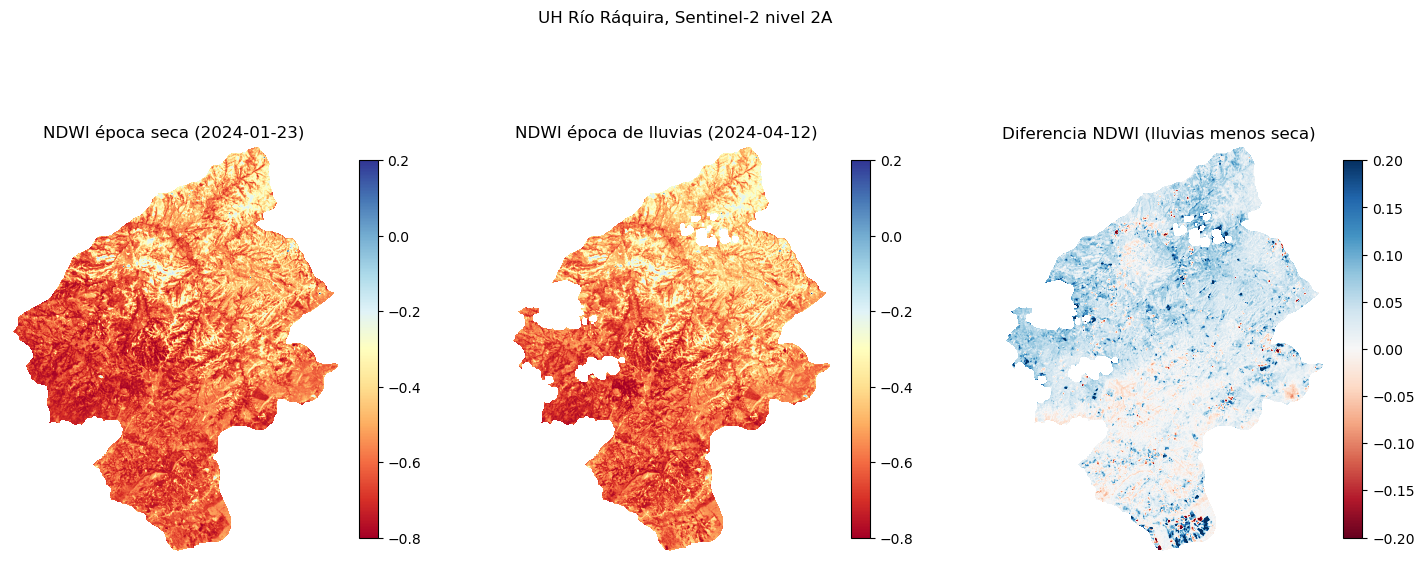

In [24]:
# Copias con NaN en los pixeles sin dato para que matplotlib no los dibuje
seca_plot = np.where(ndwi_seca[0] == -9999, np.nan, ndwi_seca[0])
lluvias_plot = np.where(ndwi_lluvias[0] == -9999, np.nan, ndwi_lluvias[0])
diferencia_plot = np.where(diferencia[0] == -9999, np.nan, diferencia[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# NDWI de la época seca
img1 = axes[0].imshow(seca_plot, cmap="RdYlBu", vmin=-0.8, vmax=0.2)
axes[0].set_title("NDWI época seca (2024-01-23)")
axes[0].axis("off")
plt.colorbar(img1, ax=axes[0], shrink=0.7)

# NDWI de la época de lluvias
img2 = axes[1].imshow(lluvias_plot, cmap="RdYlBu", vmin=-0.8, vmax=0.2)
axes[1].set_title("NDWI época de lluvias (2024-04-12)")
axes[1].axis("off")
plt.colorbar(img2, ax=axes[1], shrink=0.7)

# Diferencia
img3 = axes[2].imshow(diferencia_plot, cmap="RdBu", vmin=-0.2, vmax=0.2)
axes[2].set_title("Diferencia NDWI (lluvias menos seca)")
axes[2].axis("off")
plt.colorbar(img3, ax=axes[2], shrink=0.7)

plt.suptitle("UH Río Ráquira, Sentinel-2 nivel 2A")
plt.show()

## Histograma y estadísticas descriptivas de la diferencia
1. Se toman solo los pixeles válidos de la diferencia y se calcula el área que cubren
2. Se calculan la media, la mediana, el mínimo, el máximo y la desviación estándar
3. Se calcula el porcentaje de pixeles donde el NDWI aumentó y donde disminuyó
4. Se calcula el porcentaje de pixeles con cambios fuertes, mayores a 0.2 en valor absoluto
5. Se calcula el área de agua abierta (NDWI mayor a 0) en cada fecha, en los mismos pixeles válidos. Cada pixel de 10 m x 10 m tiene 100 m2, es decir 0.01 ha
6. Se grafica el histograma con una línea en 0 (sin cambio) y otra en la media. El eje X se limita entre -0.4 y 0.4 para ver la forma de la distribución, el mínimo y el máximo quedan en las estadísticas

=== Estadísticas de la diferencia de NDWI (lluvias menos seca) ===
Pixeles válidos: 1597244 (159.72 km2)
Media: 0.0326
Mediana: 0.0283
Mínimo: -0.5781
Máximo: 0.8037
Desviación estándar: 0.0540
Pixeles donde el NDWI aumentó: 76.9 %
Pixeles donde el NDWI disminuyó: 23.1 %
Pixeles con aumento mayor a 0.2: 1.10 %
Pixeles con disminución mayor a 0.2: 0.18 %
Agua abierta en la época seca: 7.59 ha
Agua abierta en la época de lluvias: 6.81 ha


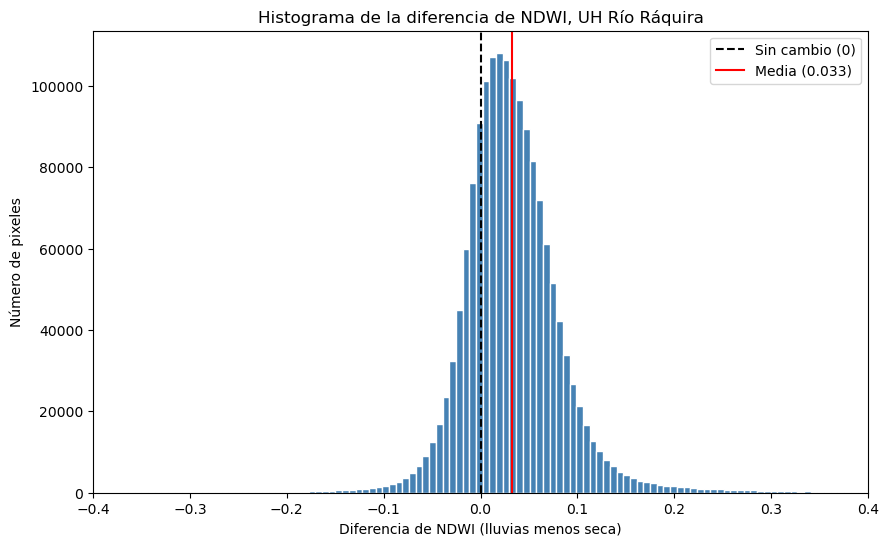

In [25]:
# 1. Pixeles válidos de la diferencia y área que cubren (cada pixel tiene 100 m2)
valores = diferencia[validos_ambas]
area_valida_km2 = len(valores) * 100 / 1000000

# 2. Estadísticas descriptivas
media = valores.mean()
mediana = np.median(valores)
minimo = valores.min()
maximo = valores.max()
desviacion = valores.std()

# 3. Porcentaje de pixeles donde el NDWI aumentó y donde disminuyó
porcentaje_aumenta = 100 * (valores > 0).sum() / len(valores)
porcentaje_disminuye = 100 * (valores < 0).sum() / len(valores)

# 4. Porcentaje de pixeles con cambios fuertes (mayores a 0.2 en valor absoluto)
porcentaje_sube_fuerte = 100 * (valores > 0.2).sum() / len(valores)
porcentaje_baja_fuerte = 100 * (valores < -0.2).sum() / len(valores)

# 5. Área de agua abierta (NDWI mayor a 0) en cada fecha, en los mismos pixeles válidos
agua_seca_ha = (ndwi_seca[validos_ambas] > 0).sum() * 0.01
agua_lluvias_ha = (ndwi_lluvias[validos_ambas] > 0).sum() * 0.01

print("=== Estadísticas de la diferencia de NDWI (lluvias menos seca) ===")
print(f"Pixeles válidos: {len(valores)} ({area_valida_km2:.2f} km2)")
print(f"Media: {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Mínimo: {minimo:.4f}")
print(f"Máximo: {maximo:.4f}")
print(f"Desviación estándar: {desviacion:.4f}")
print(f"Pixeles donde el NDWI aumentó: {porcentaje_aumenta:.1f} %")
print(f"Pixeles donde el NDWI disminuyó: {porcentaje_disminuye:.1f} %")
print(f"Pixeles con aumento mayor a 0.2: {porcentaje_sube_fuerte:.2f} %")
print(f"Pixeles con disminución mayor a 0.2: {porcentaje_baja_fuerte:.2f} %")
print(f"Agua abierta en la época seca: {agua_seca_ha:.2f} ha")
print(f"Agua abierta en la época de lluvias: {agua_lluvias_ha:.2f} ha")

# 6. Histograma de la diferencia
plt.figure(figsize=(10, 6))
plt.hist(valores, bins=200, color="steelblue", edgecolor="white")
plt.axvline(0, color="black", linestyle="--", label="Sin cambio (0)")
plt.axvline(media, color="red", label=f"Media ({media:.3f})")
plt.xlim(-0.4, 0.4)
plt.title("Histograma de la diferencia de NDWI, UH Río Ráquira")
plt.xlabel("Diferencia de NDWI (lluvias menos seca)")
plt.ylabel("Número de pixeles")
plt.legend()
plt.show()

## Mapa interactivo con las dos fechas y la diferencia
1. Se inicializa el mapa de leafmap centrado en la UH, con el control de escala, el de pantalla completa y la herramienta de dibujo
2. Se agrega la imagen satelital de Esri como mapa base
3. Se agregan las tres capas con paletas divergentes: `RdYlBu` para el NDWI de cada fecha y `RdBu` para la diferencia, centrada en 0. Se indica `nodata=-9999` para que los pixeles sin dato (por fuera de la UH y con nubes) queden transparentes y no se pinten con el color del valor mínimo
4. Se agrega el límite de la UH sin relleno
5. Se agrega la barra de colores de la diferencia, con cinco colores para que las etiquetas queden en -0.2, -0.1, 0, 0.1 y 0.2, y el minimapa
6. Se agrega el control de capas para prender y apagar cada capa
7. Se muestra el mapa

In [26]:
# 1. Crear el mapa con escala, pantalla completa y herramienta de dibujo
Map_ndwi = leafmap.Map(center=centroid, zoom=12, scale_control=True, fullscreen_control=True, draw_control=True)

# 2. Mapa base de imagen satelital
Map_ndwi.add_basemap("Esri.WorldImagery")

# 3. Capas de NDWI de cada fecha y de la diferencia
Map_ndwi.add_raster(str(tif_seca), colormap="RdYlBu", vmin=-0.8, vmax=0.2, nodata=-9999, layer_name="NDWI época seca (2024-01-23)", zoom_to_layer=False)
Map_ndwi.add_raster(str(tif_lluvias), colormap="RdYlBu", vmin=-0.8, vmax=0.2, nodata=-9999, layer_name="NDWI época de lluvias (2024-04-12)", zoom_to_layer=False)
Map_ndwi.add_raster(str(tif_diferencia), colormap="RdBu", vmin=-0.2, vmax=0.2, nodata=-9999, layer_name="Diferencia NDWI (lluvias menos seca)", zoom_to_layer=False)

# 4. Límite de la UH sin relleno
Map_ndwi.add_gdf(gdf_uh, layer_name="Límite UH Río Ráquira", style={"color": "black", "weight": 2, "fillOpacity": 0}, zoom_to_layer=False)

# 5. Barra de colores de la diferencia (colores de la paleta RdBu) y minimapa
colores_rdbu = [
    "#b2182b", # Rojo (el NDWI bajó en lluvias), -0.2
    "#f4a582", # -0.1
    "#f7f7f7", # Blanco (sin cambio), 0
    "#92c5de", # 0.1
    "#2166ac"  # Azul (el NDWI subió en lluvias), 0.2
]
Map_ndwi.add_colorbar(colores_rdbu, vmin=-0.2, vmax=0.2, caption="Diferencia NDWI (lluvias menos seca)", position="bottomleft")
Map_ndwi.add_minimap(zoom=6, position="bottomright")

# 6. Control de capas
Map_ndwi.add_layer_control()

# 7. Mostrar el mapa
Map_ndwi

Map(center=[5.503690074591818, -73.61531349657034], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## Mapa con control de comparación (split map) entre la época seca y la de lluvias
Se usa `split_map` de leafmap para comparar con un deslizador el NDWI de la época seca (izquierda) y el de la época de lluvias (derecha). Las dos capas llevan la misma paleta y el mismo rango para que los colores sean comparables. En las dos capas también se indica el nodata (-9999) para que lo que está por fuera de la UH quede transparente.

In [29]:
# Crear el mapa centrado en la UH
Map_split = leafmap.Map(center=centroid, zoom=12)

# Comparación con deslizador: época seca a la izquierda y época de lluvias a la derecha
Map_split.split_map(
    left_layer=str(tif_seca),
    right_layer=str(tif_lluvias),
    left_args={"colormap": "RdYlBu", "vmin": -0.8, "vmax": 0.2, "nodata": -9999, "layer_name": "NDWI época seca"},
    right_args={"colormap": "RdYlBu", "vmin": -0.8, "vmax": 0.2, "nodata": -9999, "layer_name": "NDWI época de lluvias"},
    left_label="Época seca (2024-01-23)",
    right_label="Época de lluvias (2024-04-12)"
)

Map_split.add_basemap("SATELLITE") # Se añade el mapa base 

Map_split

Map(center=[5.503690074591818, -73.61531349657034], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## Conclusiones
1. De los 168.63 km2 de la UH se compararon 159.72 km2 con pixel válido en las dos fechas. Lo que queda por fuera corresponde principalmente a las nubes y sombras de la escena de abril, que cubrieron el 5.4 % de la UH. La escena de enero no tenía nubes sobre la UH.
2. La diferencia de NDWI (lluvias menos seca) tiene una media de 0.033, una mediana de 0.028 y una desviación estándar de 0.054. El NDWI aumentó en el 76.9 % de los pixeles y disminuyó en el 23.1 %.
3. Los cambios son pequeños en casi toda la UH: el histograma es angosto y está centrado un poco por encima de 0. Los cambios fuertes, mayores a 0.2 en valor absoluto, son menos del 1.3 % de los pixeles (1.10 % de aumento y 0.18 % de disminución) y en el mapa de diferencia aparecen como parches localizados.
4. En el mapa de diferencia el aumento del NDWI es más extendido en la mitad norte de la UH. En la mitad sur la diferencia está más cerca de 0 y aparecen zonas con una leve disminución.
5. El agua abierta (NDWI mayor a 0) ocupa muy poca área en la UH: 7.59 ha en enero y 6.81 ha en abril, contando solo los pixeles válidos en las dos fechas. Por eso el NDWI es negativo en casi toda la UH y la diferencia muestra sobre todo el cambio en la relación entre el verde y el infrarrojo cercano de la cobertura, más que cambios en cuerpos de agua.
6. Alrededor de los huecos de nubes de abril aparecen valores altos de diferencia. Pueden ser bordes de nubes o de sombras que la banda SCL no marcó, por eso conviene revisarlos en el mapa interactivo antes de interpretarlos como un cambio real.